In [1]:
import warnings
from typing import Callable, Optional, TypeVar

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures

warnings.filterwarnings("ignore")

In [2]:
%matplotlib inline

Set random seed so that randomly generated data is the same every time.
- However library versions may affect it. This notebook is made from python 3.14.0, numpy 2.3.4, sklearn 1.7.2.
- You need to rerun everything to reproduce the same result. Rerunning a single cell may lead to different results even with the same parameters.

**You're still welcomed to tweak and explore different parameters and also try different seeds. This note is only to tell you how to reproduce the default results.**

In [3]:
np.random.seed(42)  # determinism

# Overview

In this notebook, we are going to explore the Least Square Regression (LSR) model. The main goals of this notebook are:

- Learn how to use the plug-and-play models implemented in the Python package sklearn.
- Explore the Noise-Bias-Variance Decomposition.
- Check if our estimator is unbiased.
- How to detect overfitting.
- How to avoid overfitting: regularization.


# Generating some data

First, we are going to create the functions to generate linear and sinusoidal data in the interval $x \in [0,1 ]$, adding gaussian noise.

**Linear data**: $y = wx + b + \epsilon$ with $\epsilon \sim N(0, \sigma)$

**Sinosoidal data**: $y = sin(2\pi x) + \epsilon$ with $\epsilon \sim N(0, \sigma)$

$\sim$ means "*distributed according to*"

In [4]:
# Generate data (x) uniform in the interval [0,1]
# Generate Linear y = w*x + b + epsilon
def make_linear_data(num_points: int, w: float, b: float, noise_std: float):
    # x result is of shape (num_points,) and sorted in ascending order
    x = np.sort(np.random.uniform(low=0, high=1, size=num_points))
    # https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html
    epsilon = np.random.normal(loc=0, scale=noise_std, size=num_points)
    y = w * x + b + epsilon
    return x, y


# Generate sinusoidal y = sin(2*pi*x) + epsilon
def make_sin_data(num_points: int, noise_std: float):
    x = np.sort(np.random.uniform(low=0, high=1, size=num_points))
    epsilon = np.random.normal(loc=0, scale=noise_std, size=num_points)
    y = np.sin(2 * np.pi * x) + epsilon
    return x, y


w_true = 2
b_true = 1
x_linear, y_linear = make_linear_data(100, w=w_true, b=b_true, noise_std=0.2)
x_sinus, y_sinus = make_sin_data(100, noise_std=1)

To visualize the datasets these functions produce, we can plot them:

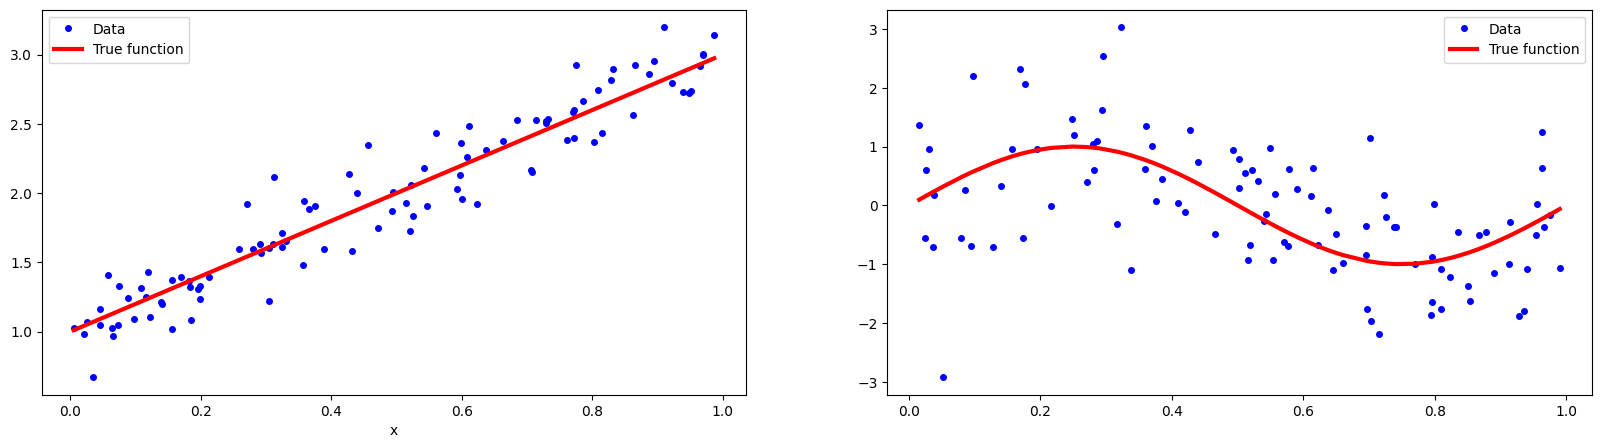

In [5]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))

# Linear data:
ax1.plot(x_linear, y_linear, "bo", markersize=4, label="Data")
ax1.plot(x_linear, w_true * x_linear + b_true, "red", linewidth=3, label="True function")
ax1.set_xlabel("x")
ax1.legend()

# Sinusoidal data:
ax2.plot(x_sinus, y_sinus, "bo", markersize=4, label="Data")
ax2.plot(x_sinus, np.sin(2 * np.pi * x_sinus), "red", linewidth=3, label="True function")
ax2.legend()

f.show()

# Least Squares Regression (LSR)
Given a dataset with $n$ i.i.d. training samples $D = (X_i, Y_i)_{i=1}^n$ and a function space $\mathcal{F}$ we define the least squares regression solution as 

$$
f_{n}^{*}=\underset{f \in \mathcal{F}}{\arg \min } \frac{1}{n} \sum_{i=1}^{n}\left(y_{i}-f\left(\mathbf{x}_{i}\right)\right)^{2}
$$

We also know that the optimal solution to LSR, i.e., the Bayes optimal function, is given by 

$$
f^{*}(\mathbf{x})=\mathbb{E}[Y \mid X=\mathbf{x}]
$$

Here we are looking at linear LSR, which assumes that the function class consists of all linear functions.
$$
\mathcal{F}=\left\{f: \mathbb{R}^{M} \rightarrow \mathbb{R}, f(\mathbf{x})=\sum_{i=1}^{M} w_{i} \phi_{i}(\mathbf{x}) \mid \mathbf{w} \in \mathbb{R}^{M}\right\},
$$

where $\phi_i$ are called basis functions $\phi_i: \mathbb{R}^d \rightarrow \mathbb{R}$ and represent transformations of the input data. Some examples of basis functions are 

$$
\phi(x) =  \Big( 1, x, x^2, \dots \Big) \\
\phi(x) =  \Big( sin(x), cos(x), \dots \Big)
$$

Note that, although clearly the basis functions produce vectors with entries that are non-linear with respect to their input, the function class still only contains linear functions (linear w.r.t the basis function entries; in other words, w.r.t. weights).

### LSR solution
As seen in the lecture (slide L04&L05, slide-no. 10), we have an explicit solution:

Let $X\in \mathcal R^{n \times M}$. Here, we assume that the first column of this matrix is full of ones, this will make the calculation easier.

Following the slides, we now simply compute: $w_{n}^* = (X^TX)^{-1}X^Ty$. Note that we can only compute the inverse of $X^TX$, if it is of full column rank. Otherwise, we must resort to the pseudo-inverse. This problem can be circumvented by using the numpy function "pinv", which equals the normal inverse if the input is invertible and returns the pseudoinverse otherwise.



In [6]:
def LSR_optimal_w_and_b(X: np.ndarray, y: np.ndarray):
    # input X is 1D (M=1) with shape (n,) equivalent to (1, n). we add ones to first column and make it shape (n, 2)
    X = np.vstack([np.ones(len(X)), X]).T
    XTX = X.T @ X
    XTX_inverse = np.linalg.pinv(XTX)
    # multiply the latter two is faster due to smaller results
    b_w = XTX_inverse @ (X.T @ y)
    # extract intercept and w-value from the solution. here we know w is scalar
    b: np.float64 = b_w[0]
    w: np.float64 = b_w[1]
    return b, w

### Applying to linear data

Now we can apply our function to our datasets and plot the resulting solutions:

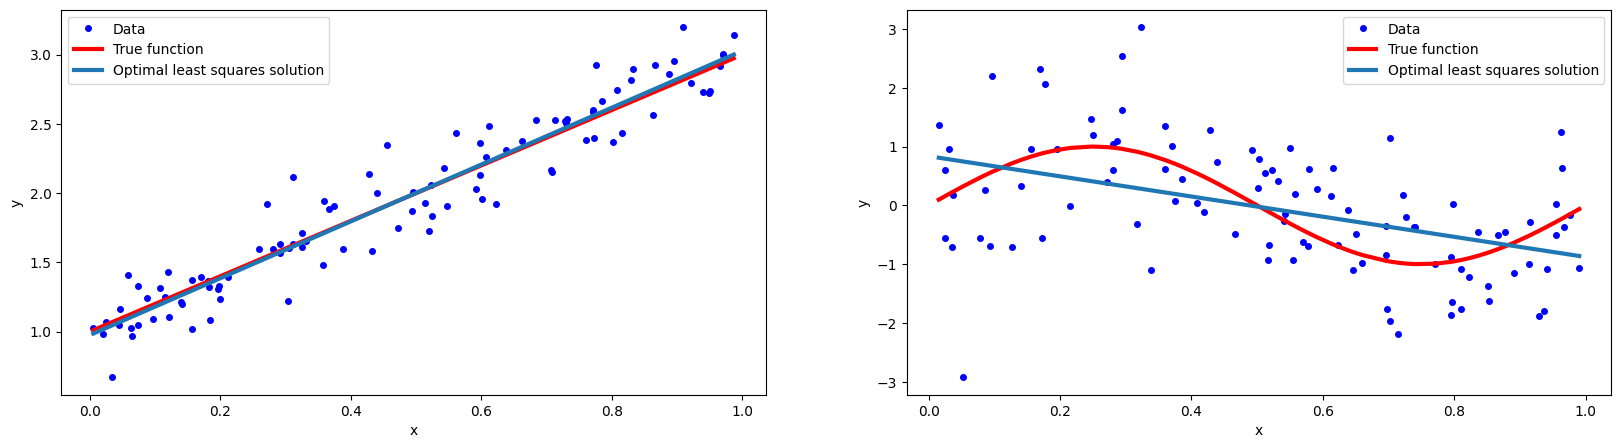

In [7]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))

# Linear data:
b_opt_linear, w_opt_linear = LSR_optimal_w_and_b(x_linear, y_linear)
ax1.plot(x_linear, y_linear, "bo", markersize=4, label="Data")
ax1.plot(x_linear, w_true * x_linear + b_true, "red", linewidth=3, label="True function")
ax1.plot(x_linear, w_opt_linear * x_linear + b_opt_linear, linewidth=3, label="Optimal least squares solution")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend()

# Sinusoidal data:
b_opt_sinus, w_opt_sinus = LSR_optimal_w_and_b(x_sinus, y_sinus)
ax2.plot(x_sinus, y_sinus, "bo", markersize=4, label="Data")
ax2.plot(x_sinus, np.sin(2 * np.pi * x_sinus), "red", linewidth=3, label="True function")
ax2.plot(x_sinus, w_opt_sinus * x_sinus + b_opt_sinus, linewidth=3, label="Optimal least squares solution")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.legend()

f.show()

## Noise-Bias-Variance Decomposition

The risk (i.e., the expected squared loss) $R(f_n)$ of the estimator $f_n$ is given by:


$$
R(f_n) =  \mathbb{E}_{X,Y}\left[ \left( Y-f_{n}(X)\right)^{2}\right]  =  \mathbb{E}\left[(Y-\mathbb{E}[Y \mid X])^{2}\right]+\mathbb{E}\left[\left(\mathbb{E}[Y \mid X]-f_{n}(X)\right)^{2}\right]
$$

In this first case, we left the estimator $f_n$ fixed. But, since $f_n$ is dependend on the sampled data $X$, we can also look at the "expected risk", taking into considerations the probabilities with which we sample every possible dataset (of size n): 

\begin{align}
\mathbb{E}_{D}\left[R\left(f_{n}\right)\right]&=\mathbb{E}\left[\left(Y-f^{*}(X)\right)^{2}\right]+\mathbb{E}_{D}\left[\mathbb{E}_{X}\left[\left(f^{*}(X)-f_{n}(X)\right)^{2}\right]\right] \\
 &=\mathbb{E}\left[\left(Y-f^{*}(X)\right)^{2}\right]+\operatorname{Var}\left(f_{n}(X)\right)+\left(\operatorname{Bias}\left(f_{n}(X)\right)\right)^{2} \\
 &= \sigma^2+\operatorname{Var}\left(f_{n}(X)\right)+\left(\operatorname{Bias}\left(f_{n}(X)\right)\right)^{2}
\end{align}

Here, we wrote $f^{*}(X)$ instead of $\mathbb{E}[Y \mid X]$ for easier readbility. For a derivation of these equations, refer to the slides (L04&L05, slide-no. 22). The $\sigma$ corresponds to the standard deviation we used to generate the noise.

**KEY POINT 1.** The first term is called "*noise term*" or "*irreducible error*". It is constant, i.e. it doesn't depend on the sampled dataset nor on the estimator. Therefore, the expectation over $D$ is fixed.

**KEY POINT 2.** The trade-off between (squared) bias and variance corresponds to the trade-off between overfitting and underfitting. The expectation $\mathbb{E}_{D}$ is basically measuring the bias and variance of an estimator at a fixed point $X=x$. Then, we apply the expectation over $\mathbb{E}_{X}$ to compute the bias and variance among all possible $X$.

### Relation to regularization:

This also is related to regularization: when using regularization in least squares regression (e.g. as we do in Lasso or Ridge Regression), we will introduce some bias (whereas the ordinary least squares regression provides unbiased estimates), but in turn we can greatly reduce variance and thus produce superior performance in general. 

# Linear data with varying amounts of noise 
Intuitively, __it should be clear that our estimator has larger variance if either the variance of the noise increases or the number of samples in the dataset decreases.__

We can test this intuition by looking at the best values of w and b, as well as the MSE, for varying levels of noise and dataset sizes:

In [8]:
# Mean Squared Error (MSE) a.k.a. Risk of squared loss
def MSE(ground_truth: np.ndarray, prediction: np.ndarray):
    return np.mean(np.square(ground_truth - prediction))

In [9]:
# one could also show that even for large variance, the correct coeff are found as n -> \infty
num_samples = 600
noise_std = 2
# Linear data used in training:
x_data, y_data = make_linear_data(num_samples, w=2, b=1, noise_std=noise_std)
# now we use sklearn instead of solving it on our own
reg = LinearRegression().fit(x_data.reshape(-1, 1), y_data)

# Linear data used in testing:
x_data, y_data = make_linear_data(num_samples * 10000, w=2, b=1, noise_std=noise_std)
prediction = reg.predict(x_data.reshape(-1, 1))
loss = MSE(y_data, prediction)

print(f"w_n: {reg.coef_[0]:.3f}")
print(f"b_n: {reg.intercept_:.3f}")
print(f"MSE: {loss:.3f} | Irreducible error: {noise_std**2:.3f}")

w_n: 1.671
b_n: 1.360
MSE: 4.048 | Irreducible error: 4.000


__Note:__ You can experiment with the code snippet above, change the training size and comment on the MSE and compare model parameters $w_n$ and $b_n$ with the true values. And, then change the variance of the noise applied to data and comment on them again.

### Visualizing the distributions of $w_{n}$ and $b_{n}$

To get a better look at how much the $w_{n}$ and $b_{n}$ vary with different datasets, we can run a more thorough experiment:

Questions we might ask is:
1.   Is our estimator unbiased?

    -> Do our samples on expectation match the true w and b that were used for generating the data?
2.   How does the estimator change with n (dataset size)

    -> We can plot a histogram to find out how it is distributed

This part of the notebook is refering to the __Bias-variance__ section in slide L04&L05.

E[w_n] is approximately 2.002, the true value is 2. Var[w_n] is approximately 0.121.
E[b_n] is approximately 0.999, the true value is 1. Var[b_n] is approximately 0.040.



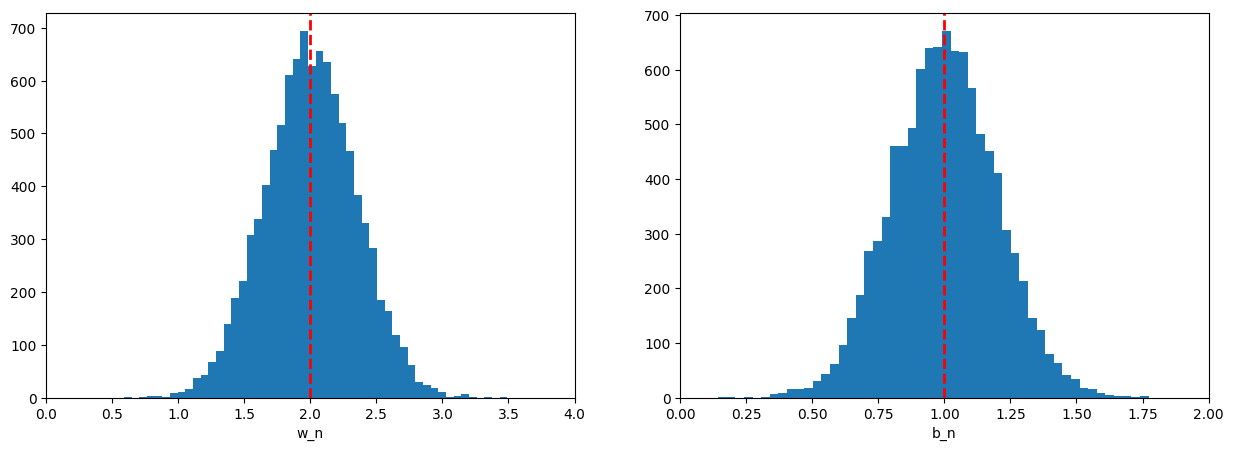

In [10]:
# We first decide the true value of the parameters w and b and variance of epsilon
w_true, b_true, noise_std = 2, 1, 1

N = 100  # Number of datapoints per dataset D

W_ns, B_ns = [], []

for _ in range(10000):  # Changing this value does not change the distribution.
    x_data, y_data = make_linear_data(N, w_true, b_true, noise_std)
    reg = LinearRegression().fit(x_data.reshape(-1, 1), y_data)
    W_ns.append(reg.coef_[0])  # Extract w_n from the result
    B_ns.append(reg.intercept_)  # Extract b_n from the result

print(
    f"E[w_n] is approximately {np.mean(W_ns):.3f}, the true value is {w_true}. Var[w_n] is approximately {np.var(W_ns, ddof=1):.3f}."
)
print(
    f"E[b_n] is approximately {np.mean(B_ns):.3f}, the true value is {b_true}. Var[b_n] is approximately {np.var(B_ns, ddof=1):.3f}.\n"
)


fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].hist(W_ns, bins=50, density=False)
ax[0].axvline(w_true, color="r", linestyle="dashed", linewidth=2)
ax[0].set_xlabel("w_n")

ax[1].hist(B_ns, bins=50, density=False)
ax[1].axvline(b_true, color="r", linestyle="dashed", linewidth=2)
ax[1].set_xlabel("b_n")

# Fix the axis such that the plots are always comparable with new data
ax[0].set_xlim([0, 4])
ax[1].set_xlim([0, 2])

plt.show()

Side note: remember the central limit theorem? cf. Block1 notebook :)

# Introducing basis functions

Basis functions can be used to apply linear regression methods, even though the relationship between the input features (x) and the outputs (target value, y) is *not* linear. We do this by transforming our input feature into a new space (of generally higher dimension) in which the relationship between the input and output is now linear.

**Example:**
For example, we can use polynomials as the basis function: $\phi(x) = [1, x, x^2, ...,  x^p]$. For example, in a 1-D regression problem, $X$ would be $\in \mathcal R^{n\times 1}$. If we apply the above polynomial basis function (for some finite p), the new, "transformed" dataset will be of shape $X \in \mathcal R^{n \times (p+1)}$. The original one-dimensional datapoint $2$ would be transformed to the (p+1)-dimensional datapoint $(1,2,4,\dots, 2^p)$.

**Questions we might ask:**
1.   How does the training/test error vary with $p$?

    -> We can plot the MSE's (prediction vs. ground truth, for both train and test data) on the y-Axis, and p on the x-Axis. 
    
2.   How can we relate what we find to the concepts of under-/overfitting and the bias-variance trade-off?

3.   How can we pick a suitable value for $p$, without relying on the test data?


To find out more, we first write a function that gives us, for all degrees up to some limit, the train and test errors:

In [11]:
T = TypeVar("T", LinearRegression, Lasso, Ridge)


# Parameter generator: a function that takes in a size (n) and returns a dataset
# Parameter regressor: either LinearRegression or Ridge or Lasso (all are classes from sklearn) all of them performs Least Squares Regression and regularization if applies.
def evaluate_models(
    max_p: int,
    train_data: tuple[np.ndarray, np.ndarray],
    test_data: tuple[np.ndarray, np.ndarray],
    regressor: Callable[[], T],
):
    x_train, y_train = train_data
    x_test, y_test = test_data

    training_errors: list[np.floating] = []
    test_errors: list[np.floating] = []
    models: list[T] = []
    for i in range(max_p):
        # The [:,None] part converts from shape (n,) to shape (n,1)
        # See https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html#sklearn.preprocessing.PolynomialFeatures.transform
        features = PolynomialFeatures(i + 1).fit(x_train[:, None])
        X_train = features.transform(x_train[:, None])
        X_test = features.transform(x_test[:, None])

        model = regressor().fit(X_train, y_train)
        models.append(model)

        training_errors.append(MSE(model.predict(X_train), y_train))
        test_errors.append(MSE(model.predict(X_test), y_test))
    return training_errors, test_errors, models

Now we can plot the MSE values (y-Axis) with the values for p (x-Axis):

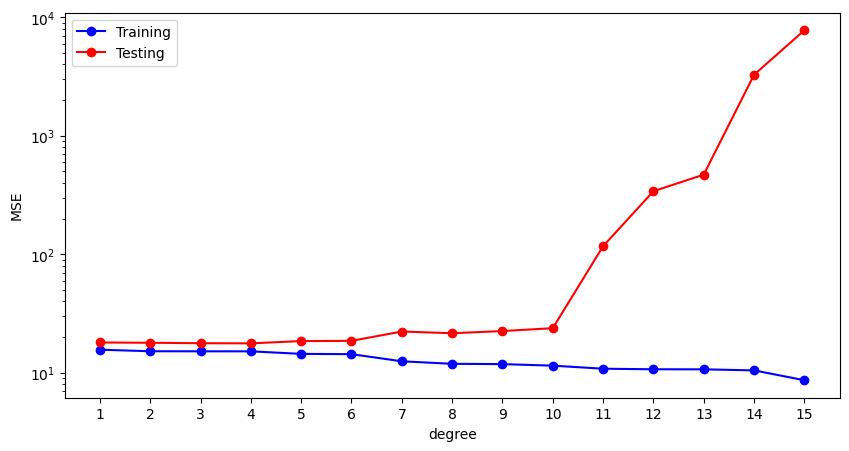

In [12]:
train_size, test_size = 30, 100

w_true, b_true, std = 2, 1, 4


# generator is now a function taking only one argument (size) and passing it to make_linear_data
generator = lambda size: make_linear_data(size, w_true, b_true, std)
regressor = LinearRegression

train_data = generator(train_size)
test_data = generator(test_size)

max_p = 15
training_errors, test_errors, models = evaluate_models(max_p, train_data, test_data, regressor)

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, max_p + 1), training_errors, "bo-", label="Training")
plt.plot(np.arange(1, max_p + 1), test_errors, "ro-", label="Testing")
plt.legend()
plt.xlabel("degree")
plt.ylabel("MSE")
plt.xticks(np.arange(1, max_p + 1))
plt.yscale("log")  # MSE can explode by orders of magnitude at high deg
plt.show()

For the higher values of p, we observe overfitting!


# Model selection using the *sinusoidal* data

We can perform a similar analysis for the sinusoidal data:

In [13]:
def plot_error_curves(
    train_errors: list[np.floating],
    test_errors: list[np.floating],
    ax: Optional[Axes] = None,
    max_p: int = 10,
    start_p: int = 0,  # we start at this plus 1
):

    if ax is None:
        ax = plt.gca()
    ax.plot(np.arange(1 + start_p, max_p + 1), train_errors[start_p:], "bo-", label="Training")
    ax.plot(np.arange(1 + start_p, max_p + 1), test_errors[start_p:], "ro-", label="Testing")
    ax.legend()
    ax.set_xlabel("degree")
    ax.set_ylabel("MSE")
    ax.set_xlim(start_p, max_p + 1)
    ax.set_xticks(np.arange(1 + start_p, max_p + 1))

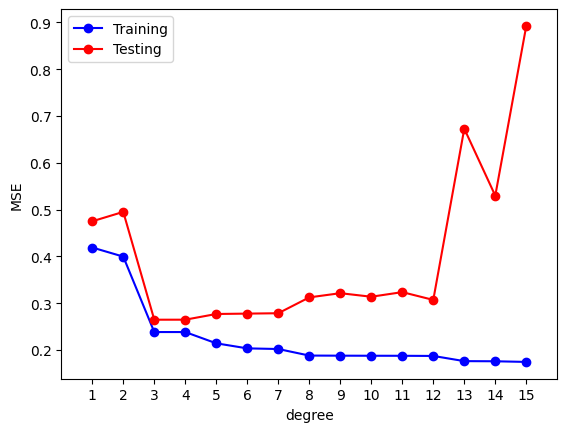

In [14]:
std = 0.5
train_size, test_size = 50, 500
generator = lambda size: make_sin_data(size, std)
regressor = LinearRegression
train_data = generator(train_size)
test_data = generator(test_size)

max_p = 15
training_errors, test_errors, models = evaluate_models(max_p, train_data, test_data, regressor)
plot_error_curves(training_errors, test_errors, max_p=max_p)
plt.show()

### Question
Why is the training and test MSE can be high with p<2?

In [15]:
# We can check the same figure with p >= 2 (uncomment the following line to run)
# plot_error_curves(training_errors, test_errors, max_p=15, start_p=2)

Clearly, we observe overfitting (check how test MSE is increasing as the model gets more complex p>>1). We can use regularization to combat this:

## Regularization: Ridge and Lasso

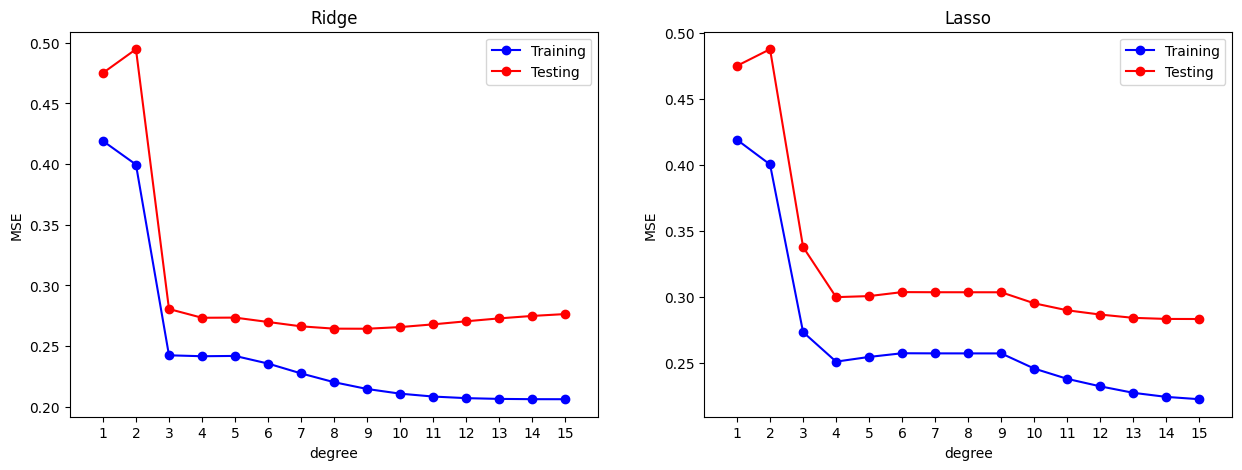

In [16]:
ridge_regressor = lambda: Ridge(alpha=0.001)
lasso_regressor = lambda: Lasso(alpha=0.001)

max_p = 15
ridge_train_error, ridge_test_error, ridge_models = evaluate_models(max_p, train_data, test_data, ridge_regressor)
lasso_train_error, lasso_test_error, lasso_models = evaluate_models(max_p, train_data, test_data, lasso_regressor)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].set_title("Ridge")
axes[1].set_title("Lasso")
plot_error_curves(ridge_train_error, ridge_test_error, axes[0], max_p=max_p, start_p=0)
plot_error_curves(lasso_train_error, lasso_test_error, axes[1], max_p=max_p, start_p=0)

From these plots, we see that we can indeed prevent overfitting when using regularization.

## Plotting the predictions

To finish up, we can plot the predictions on some test data, for both our Lasso and Ridge models:

In [17]:
def plot_predictions(
    left_models: list[T],
    lasso_models: list[Lasso],
    axes,
    test_data: tuple[np.ndarray, np.ndarray],
    true_values: tuple[np.ndarray, np.ndarray],
    train_data: tuple[np.ndarray, np.ndarray],
    name_left_plot: str = "Ridge",
):
    x_test = test_data[0]
    for i, (left_model, lasso_model) in enumerate(zip(left_models, lasso_models)):
        feature = PolynomialFeatures(i + 1).fit(x_test[:, None])
        X_test = feature.transform(x_test[:, None])

        left_pred = left_model.predict(X_test)
        ax: Axes = axes[i, 0]
        ax.set_title(f"{name_left_plot} with Polynomial of degree {i+1}")
        ax.plot(true_values[0], true_values[1], "black", label="True process")
        ax.plot(train_data[0], train_data[1], "bo", label="Train data", alpha=0.5)
        ax.plot(test_data[0], test_data[1], "ro", label="Test data", alpha=0.5)
        ax.plot(x_test, left_pred, "k--", label="Model")
        ax.legend()

        lasso_pred = lasso_model.predict(X_test)
        ax: Axes = axes[i, 1]
        ax.set_title(f"Lasso with Polynomial of degree %d" % (i + 1))
        ax.plot(true_values[0], true_values[1], "black", label="True process")
        ax.plot(train_data[0], train_data[1], "bo", label="Train data", alpha=0.5)
        ax.plot(test_data[0], test_data[1], "ro", label="Test data", alpha=0.5)
        ax.plot(x_test, lasso_pred, "k--", label="Model")
        ax.legend()

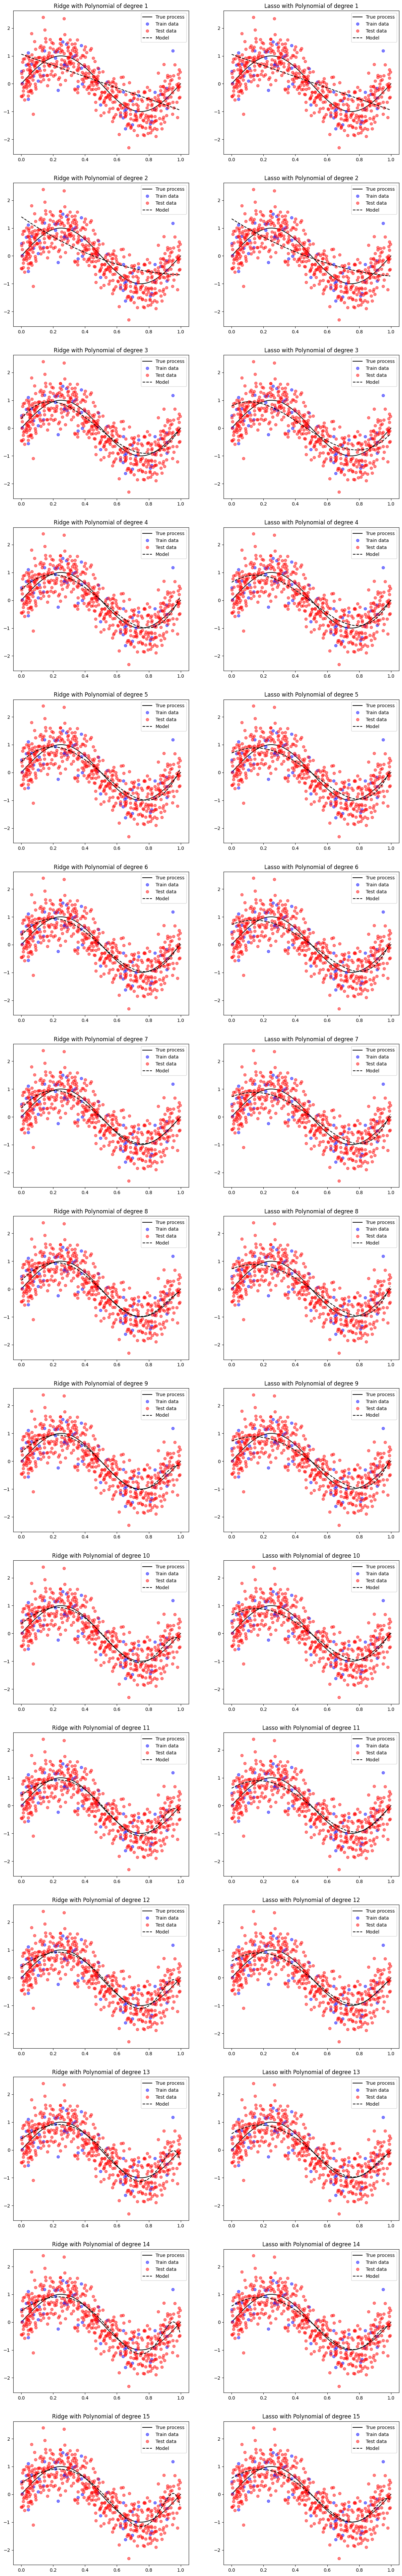

In [18]:
train_size = 50
test_size = 500
train_data = generator(train_size)
test_data = generator(test_size)
x = np.linspace(0, 1, 1000)
true_values = (x, np.sin(2 * np.pi * x))
x_test = test_data[0]
x_train = train_data[0]
fig, axes = plt.subplots(max_p, 2, figsize=(15, 100))
plot_predictions(ridge_models, lasso_models, axes, test_data, true_values, train_data)

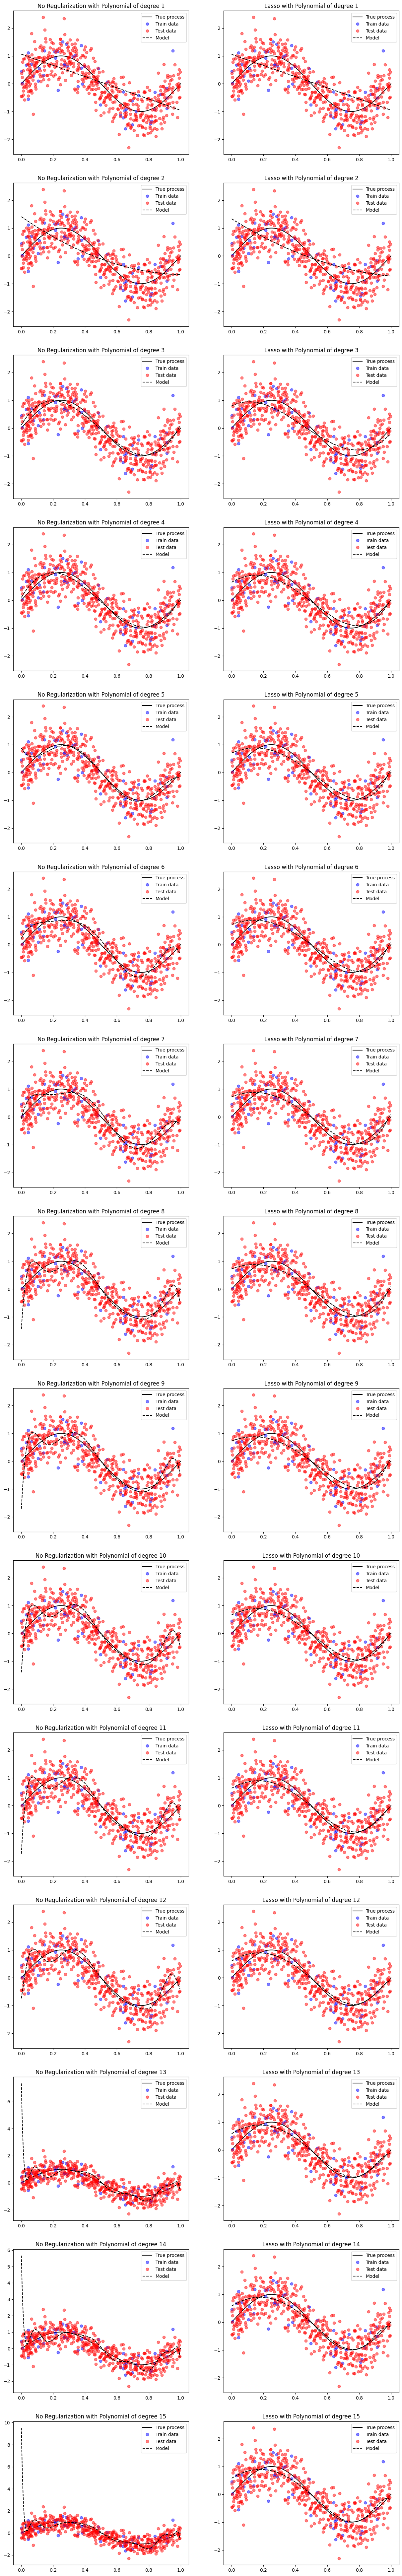

In [19]:
fig, axes = plt.subplots(max_p, 2, figsize=(15, 100))
plot_predictions(models, lasso_models, axes, test_data, true_values, train_data, name_left_plot="No Regularization")

## Comparing the learned parameters of Ridge and Lasso:

As you might know, using the L1 norm as regularization (Lasso) produces parameters that are more sparse. Remember that $w_{0}} We can confirm this by plotting histograms of the parameters:

In [20]:
def plot_parameter(ridge_models: list[Ridge], lasso_models: list[Lasso], axes):
    for i, (ridge_model, lasso_model) in enumerate(zip(ridge_models, lasso_models)):
        ridge_coeff = np.concatenate((np.array([ridge_model.intercept_]), ridge_model.coef_[1:]))
        lasso_coeff = np.concatenate((np.array([lasso_model.intercept_]), lasso_model.coef_[1:]))
        ax: Axes = axes[i, 0]
        ax.set_title("Ridge with Polynomial of degree %d" % (i + 1))
        ax.bar(range(len(ridge_coeff)), ridge_coeff, width=0.5)
        ax.set_xticks(range(len(ridge_coeff)))
        ax.set_yticks(range(-10, 10, 1))
        ax: Axes = axes[i, 1]
        ax.set_title("Lasso with Polynomial of degree %d" % (i + 1))
        ax.bar(range(len(lasso_coeff)), lasso_coeff, width=0.5)
        ax.set_xticks(range(len(lasso_coeff)))
        ax.set_yticks(range(-10, 10, 1))

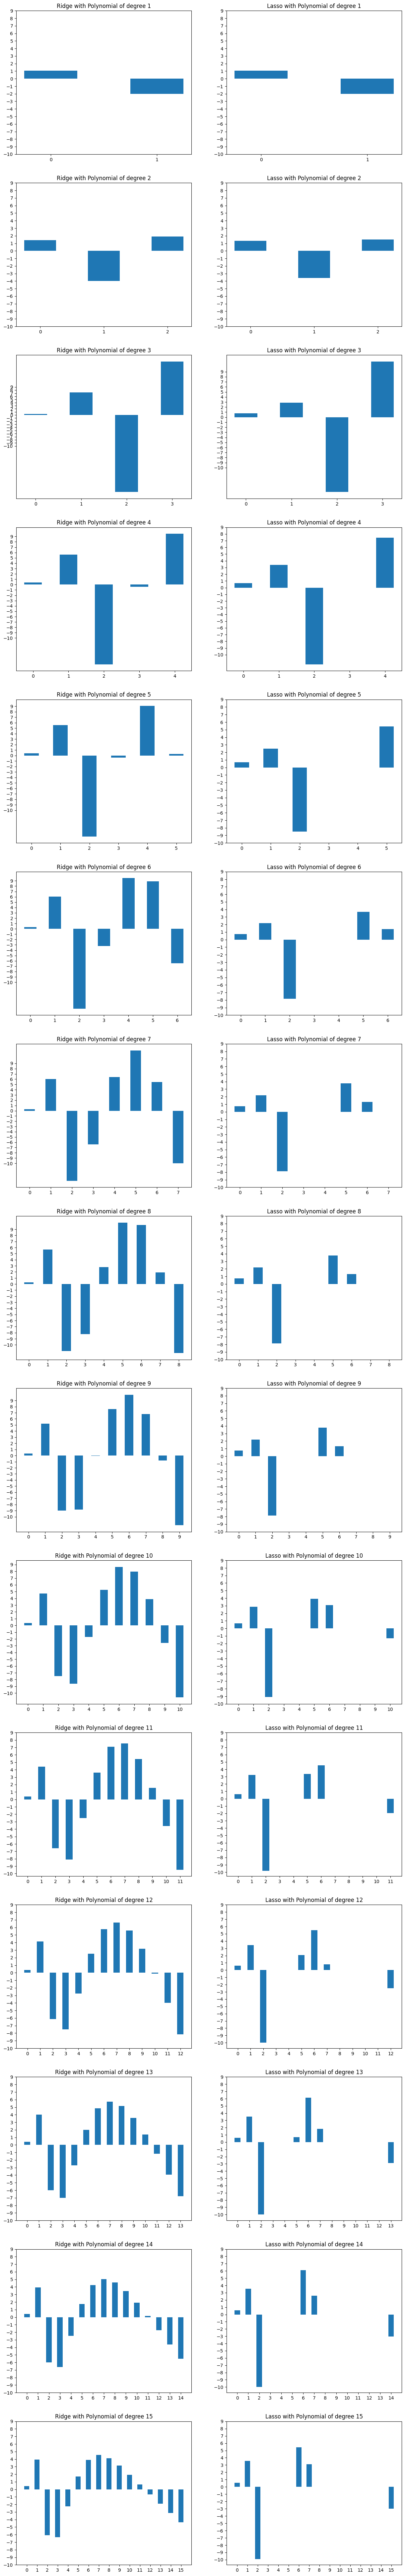

In [21]:
fig, axes = plt.subplots(max_p, 2, figsize=(15, 100))
plot_parameter(ridge_models, lasso_models, axes)

### Question
Plot the regularization parameter lambda (alpha in the sklearn object, see [here](#regularization-ridge-and-lasso)) in the x-axis versus the training/test MSE in the y-axis for different values of p (degree of the polynomial). For which values of lambda does overfitting happen? and underfitting?

In [22]:
# You answer:

Let's put all things we discussed together

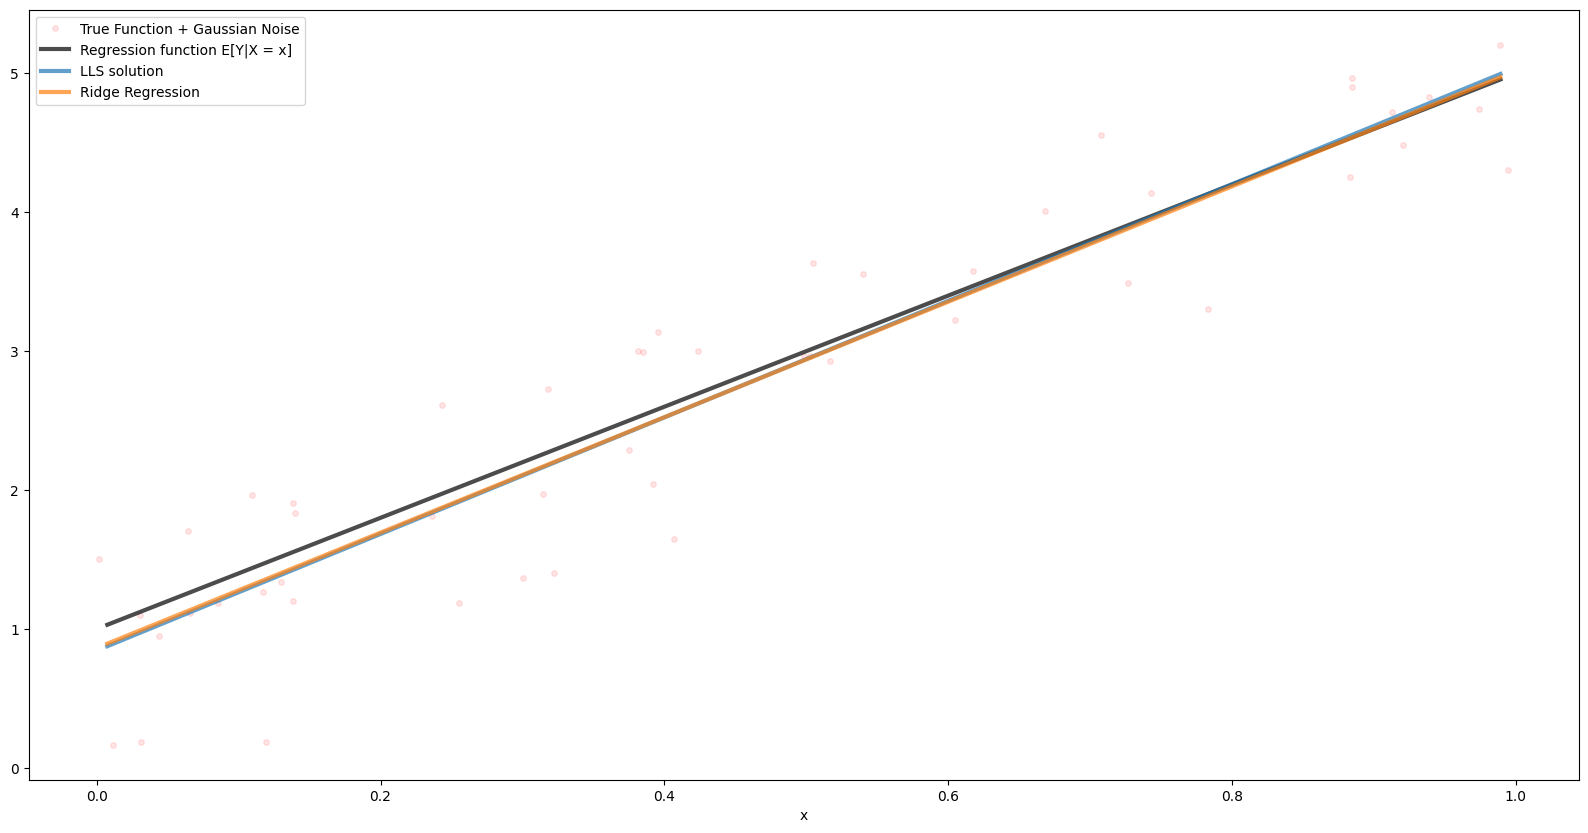

In [23]:
w_true = 4
b_true = 1
x_linear, y_linear = make_linear_data(50, w=w_true, b=b_true, noise_std=0.5)
x_linear_test, y_linear_test = make_linear_data(100, w=w_true, b=b_true, noise_std=0.5)

# Linear regression:
LR_model = LinearRegression().fit(x_linear.reshape(-1, 1), y_linear)
lr_pred = LR_model.predict(x_linear_test.reshape(-1, 1))

# Ridge regression
ridge_model = Ridge(alpha=0.05)
ridge_model = ridge_model.fit(x_linear.reshape(-1, 1), y_linear)
ridge_preds = ridge_model.predict(x_linear_test.reshape(-1, 1))

f, (ax1) = plt.subplots(1, 1, figsize=(20, 10))
ax1.plot(x_linear, y_linear, "ro", markersize=4, label="True Function + Gaussian Noise", alpha=0.1)  # Train
ax1.plot(x_linear_test, w_true * x_linear_test + b_true, "black", linewidth=3, label="Regression function E[Y|X = x]", alpha=0.7)
ax1.plot(x_linear_test, LR_model.coef_[0] * x_linear_test + LR_model.intercept_, linewidth=3, label="LLS solution", alpha=0.7)
ax1.plot(x_linear_test, ridge_model.coef_[0] * x_linear_test + ridge_model.intercept_, linewidth=3, label="Ridge Regression", alpha=0.7)
ax1.set_xlabel("x")
ax1.legend()
f.show()

(500,)


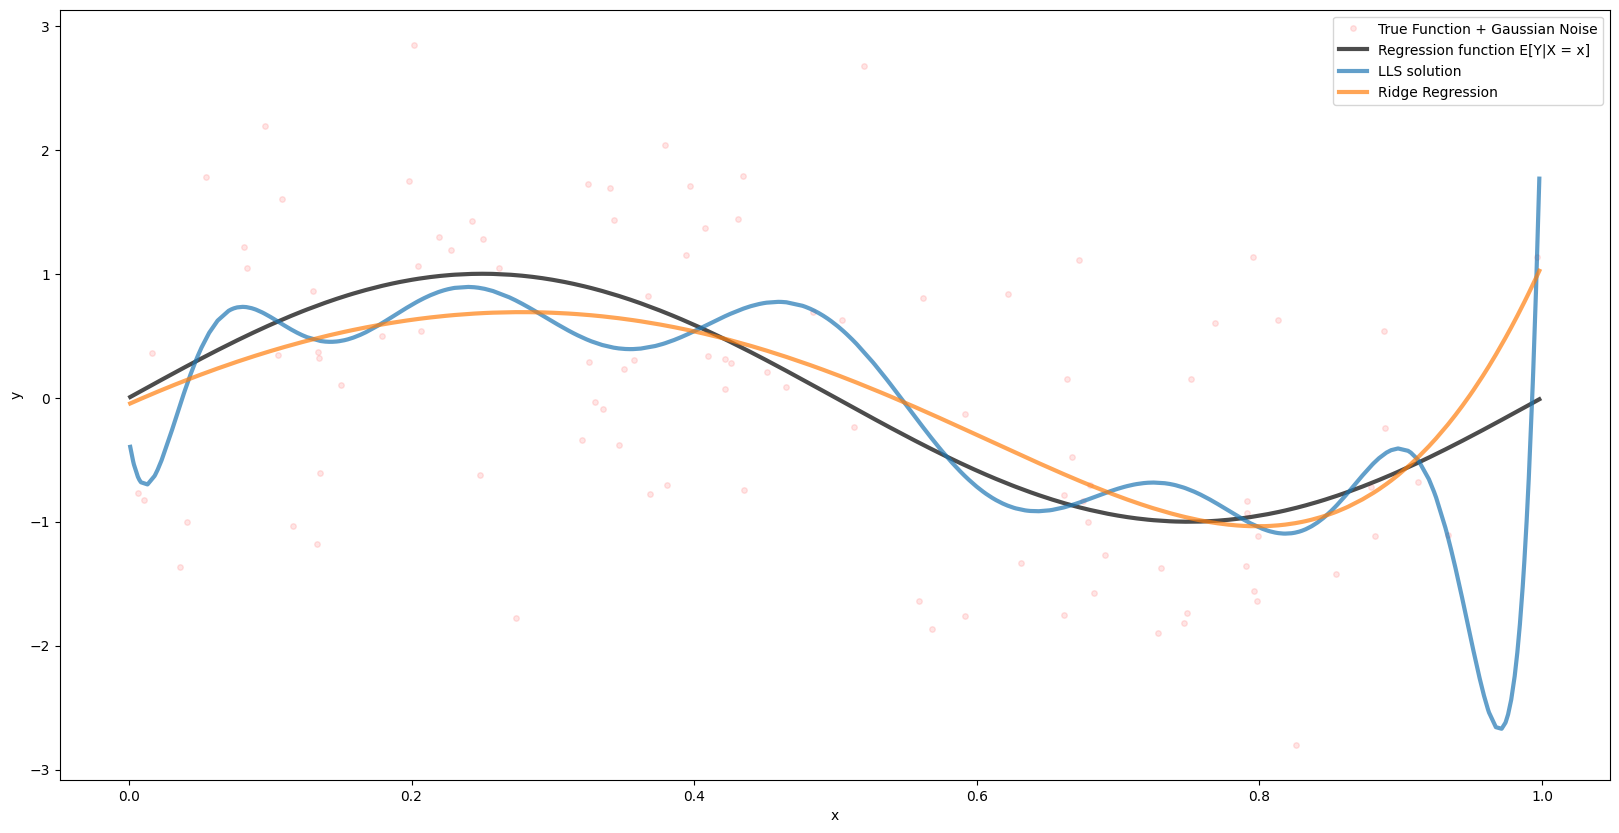

In [24]:
# Sinosodial part
x_sinus, y_sinus = make_sin_data(100, noise_std=1)
x_sinus_test, y_sinus_test = make_sin_data(500, noise_std=1)

features = PolynomialFeatures(12).fit(x_sinus[:, None])
X_train = features.transform(x_sinus[:, None])
X_test = features.transform(x_sinus_test[:, None])

# Linear regression:
LR_model = LinearRegression().fit(X_train, y_sinus)
lr_pred = LR_model.predict(X_test)
print(lr_pred.shape)
# Ridge regression
ridge_model = Ridge(alpha=0.01)
ridge_model = ridge_model.fit(X_train, y_sinus)
ridge_preds = ridge_model.predict(X_test)

f, (ax1) = plt.subplots(1, 1, figsize=(20, 10))
ax1.plot(x_sinus, y_sinus, "ro", markersize=4, label="True Function + Gaussian Noise", alpha=0.1)
ax1.plot(x_sinus_test, np.sin(2 * np.pi * x_sinus_test), "black", linewidth=3, label="Regression function E[Y|X = x]", alpha=0.7)
ax1.plot(x_sinus_test, lr_pred, linewidth=3, label="LLS solution", alpha=0.7)
ax1.plot(x_sinus_test, ridge_preds, linewidth=3, label="Ridge Regression", alpha=0.7)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend()
f.show()

We can clearly see how regularization helps to generalize better compared to simple least squares regression model.